# Assignment 6 — Denoising Autoencoder (DAE)
CSE4261/CSE4262 — Neural Network and Deep Learning

**What was wrong with the original notebook and what changed:**
1. **Dataset drift** — the assignment specifies CIFAR-10. The original notebook started on CIFAR-10 (cell 2) but then silently switched to Fashion-MNIST for the rest of the analysis (cells 3–4), so the actual noise-level / architecture study was never done on the required dataset. Everything below runs on CIFAR-10.
2. **"Max unpooling" wasn't implemented** — the original "Model 2" used `UpSampling2D` (nearest-neighbor resize) for both notebooks and simply labeled it "unpooling style." That is not max unpooling. True max unpooling requires remembering *which* location the max came from during pooling (the pooling indices/argmax) and scattering values back to exactly those locations. Implemented properly below with a custom `MaxPoolingWithArgmax2D` / `MaxUnpooling2D` layer pair (SegNet-style), so Transposed Convolution vs. Max Unpooling is now a real, like-for-like comparison, as the assignment asks.
3. **No systematic noise-level study** — the original notebook trained one model at one noise level, once. The assignment asks to "analyze the effect of noise levels on reconstruction quality" and "examine the impact of encoder architecture choices and upsampling techniques" — that requires a grid: {noise type} × {noise level} × {encoder depth} × {decoder type}. Added below.
4. **Test set reused as validation** — same leakage pattern as the CNN assignment; fixed with a proper held-out validation split.
5. **Salt-and-pepper noise was applied per-channel independently** rather than per-pixel, which doesn't match the standard definition of salt-and-pepper noise on color images (a corrupted pixel should go fully black/white across all channels, not just one channel). Fixed.
6. **No reconstruction-loss table across configs, no quantitative analysis of noise level / architecture effects** — the grid search fit models with `verbose=0` and never stored loss; only PSNR/SSIM were computed on Fashion-MNIST. Added structured results (loss + PSNR + SSIM) with comparison plots.
7. **Missing: "propose methods to address limited annotated ground truth data"** — this was not addressed anywhere in the original notebook. Added a discussion cell at the end.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models
from skimage.metrics import peak_signal_noise_ratio, structural_similarity
import random

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ==============================
# Load CIFAR-10 (as required by the assignment)
# ==============================
(x_train_full, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()
x_train_full = x_train_full.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Held-out validation split (test set is untouched until final evaluation)
val_size = 5000
x_val = x_train_full[:val_size]
x_train = x_train_full[val_size:]

print("Train:", x_train.shape, "Val:", x_val.shape, "Test:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1561s 9us/step
Train: (45000, 32, 32, 3) Val: (5000, 32, 32, 3) Test: (10000, 32, 32, 3)


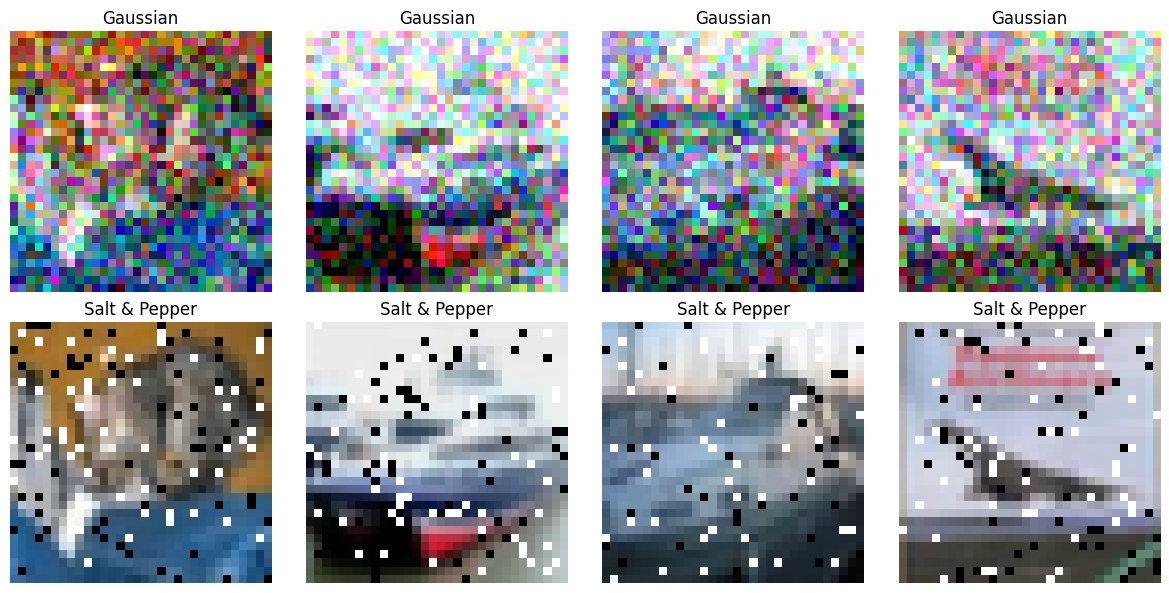

In [2]:
# ==============================
# Noise functions
# ==============================
def add_gaussian_noise(images, sigma):
    noise = np.random.normal(0, sigma, images.shape)
    return np.clip(images + noise, 0., 1.).astype('float32')

def add_salt_pepper_noise(images, amount):
    """Corrupts whole pixels (all channels) to black/white, per-pixel, not per-channel."""
    noisy = images.copy()
    n, h, w, c = images.shape
    num_pixels = int(amount * n * h * w)

    salt_n = np.random.randint(0, n, num_pixels // 2)
    salt_h = np.random.randint(0, h, num_pixels // 2)
    salt_w = np.random.randint(0, w, num_pixels // 2)
    noisy[salt_n, salt_h, salt_w, :] = 1.0

    pepper_n = np.random.randint(0, n, num_pixels // 2)
    pepper_h = np.random.randint(0, h, num_pixels // 2)
    pepper_w = np.random.randint(0, w, num_pixels // 2)
    noisy[pepper_n, pepper_h, pepper_w, :] = 0.0

    return noisy

def make_noisy(images, noise_type, level):
    if noise_type == "gaussian":
        return add_gaussian_noise(images, sigma=level)
    else:
        return add_salt_pepper_noise(images, amount=level)

# Quick visual sanity check
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
demo_gauss = add_gaussian_noise(x_test[:4], sigma=0.2)
demo_sp = add_salt_pepper_noise(x_test[:4], amount=0.1)
for i in range(4):
    axes[0, i].imshow(demo_gauss[i]); axes[0, i].set_title("Gaussian"); axes[0, i].axis('off')
    axes[1, i].imshow(demo_sp[i]); axes[1, i].set_title("Salt & Pepper"); axes[1, i].axis('off')
plt.tight_layout(); plt.show()

In [3]:
# ==============================
# Custom layers for TRUE max unpooling (SegNet-style)
# Keras has no built-in max-unpooling layer, so pooling indices (argmax) must
# be captured during pooling and used to scatter values back to their exact
# original spatial location during decoding.
# ==============================
class MaxPoolingWithArgmax2D(layers.Layer):
    def __init__(self, pool_size=(2, 2), strides=(2, 2), padding='SAME', **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size
        self.strides = strides
        self.padding = padding

    def call(self, inputs):
        output, argmax = tf.nn.max_pool_with_argmax(
            inputs,
            ksize=[1, self.pool_size[0], self.pool_size[1], 1],
            strides=[1, self.strides[0], self.strides[1], 1],
            padding=self.padding
        )
        return output, tf.cast(argmax, tf.int64)


class MaxUnpooling2D(layers.Layer):
    def __init__(self, pool_size=(2, 2), **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size

    def call(self, inputs):
        updates, mask = inputs
        in_shape = tf.cast(tf.shape(updates), tf.int64)
        batch, h, w, c = in_shape[0], in_shape[1], in_shape[2], in_shape[3]
        out_h, out_w = h * self.pool_size[0], w * self.pool_size[1]

        flat_updates = tf.reshape(updates, [-1])
        mask = tf.cast(mask, tf.int64)

        batch_range = tf.reshape(tf.range(batch, dtype=tf.int64), [-1, 1, 1, 1])
        b = tf.reshape(tf.ones_like(mask) * batch_range, [-1])
        flat_mask = tf.reshape(mask, [-1])

        flat_indices = b * (out_h * out_w * c) + flat_mask
        out_shape = tf.reshape(batch * out_h * out_w * c, [1])

        ret = tf.scatter_nd(tf.expand_dims(flat_indices, 1), flat_updates, shape=out_shape)
        ret = tf.reshape(ret, [batch, out_h, out_w, c])

        # Restore static shape info (lost via dynamic tf.shape ops) so that
        # subsequent Conv2D layers know the channel dimension at build time.
        static_shape = updates.shape
        static_h = static_shape[1] * self.pool_size[0] if static_shape[1] is not None else None
        static_w = static_shape[2] * self.pool_size[1] if static_shape[2] is not None else None
        static_c = static_shape[3]
        ret.set_shape([None, static_h, static_w, static_c])
        return ret

In [4]:
# ==============================
# Encoder / decoder builders
# encoder_type: 'shallow' (2 conv+pool blocks) vs 'deep' (3 conv+pool blocks)
# decoder_type: 'transpose' (Conv2DTranspose) vs 'unpool' (true max unpooling)
# ==============================
INPUT_SHAPE = (32, 32, 3)
OUT_CHANNELS = 3

def encoder_plain(inp, depth):
    filt = [32, 64] if depth == 'shallow' else [32, 64, 128]
    x = inp
    for f in filt:
        x = layers.Conv2D(f, 3, activation='relu', padding='same')(x)
        x = layers.MaxPooling2D(2, padding='same')(x)
    return x

def encoder_argmax(inp, depth):
    filt = [32, 64] if depth == 'shallow' else [32, 64, 128]
    x = inp
    masks = []
    for f in filt:
        x = layers.Conv2D(f, 3, activation='relu', padding='same')(x)
        x, m = MaxPoolingWithArgmax2D()(x)
        masks.append(m)
    return x, masks, filt

def decoder_transpose(encoded, depth):
    filt = [64, 32] if depth == 'shallow' else [128, 64, 32]
    x = encoded
    for f in filt:
        x = layers.Conv2DTranspose(f, 3, strides=2, activation='relu', padding='same')(x)
    return layers.Conv2D(OUT_CHANNELS, 3, activation='sigmoid', padding='same')(x)

def decoder_unpool(encoded, masks, filt):
    rev_filt = filt[::-1]        # e.g. [128,64,32] or [64,32]
    rev_masks = masks[::-1]
    x = encoded
    for i, m in enumerate(rev_masks):
        x = MaxUnpooling2D()([x, m])
        next_f = rev_filt[i + 1] if i + 1 < len(rev_filt) else rev_filt[i] // 2
        x = layers.Conv2D(next_f, 3, activation='relu', padding='same')(x)
    return layers.Conv2D(OUT_CHANNELS, 3, activation='sigmoid', padding='same')(x)

def build_model(encoder_type='shallow', decoder_type='transpose'):
    inp = layers.Input(shape=INPUT_SHAPE)
    if decoder_type == 'unpool':
        encoded, masks, filt = encoder_argmax(inp, encoder_type)
        out = decoder_unpool(encoded, masks, filt)
    else:
        encoded = encoder_plain(inp, encoder_type)
        out = decoder_transpose(encoded, encoder_type)
    return models.Model(inp, out)

# sanity check: shapes must round-trip back to 32x32x3 for every combo
for enc in ['shallow', 'deep']:
    for dec in ['transpose', 'unpool']:
        m = build_model(enc, dec)
        assert m.output_shape[1:] == INPUT_SHAPE, (enc, dec, m.output_shape)
        print(f"{enc:8s} + {dec:9s} -> output {m.output_shape}, params {m.count_params():,}")

shallow  + transpose -> output (None, 32, 32, 3), params 75,651
shallow  + unpool    -> output (None, 32, 32, 3), params 42,915
deep     + transpose -> output (None, 32, 32, 3), params 333,955
deep     + unpool    -> output (None, 32, 32, 3), params 190,563


In [5]:
# ==============================
# Metrics
# ==============================
def evaluate_metrics(original, reconstructed, n=200):
    n = min(n, len(original))
    psnr_vals, ssim_vals = [], []
    for i in range(n):
        psnr_vals.append(peak_signal_noise_ratio(original[i], reconstructed[i], data_range=1))
        ssim_vals.append(structural_similarity(original[i], reconstructed[i], data_range=1, channel_axis=-1))
    return float(np.mean(psnr_vals)), float(np.mean(ssim_vals))

In [7]:
GRID_TRAIN_SIZE = 10000
x_train_grid = x_train[:GRID_TRAIN_SIZE]

noise_types = ["gaussian", "sp"]
noise_levels = [0.05, 0.1, 0.2]
encoder_types = ["shallow", "deep"]
decoder_types = ["transpose", "unpool"]

results = []

for noise_type in noise_types:
    for level in noise_levels:
        x_train_noisy = make_noisy(x_train_grid, noise_type, level)
        x_val_noisy = make_noisy(x_val, noise_type, level)

        for enc in encoder_types:
            for dec in decoder_types:
                tf.keras.backend.clear_session()
                model = build_model(enc, dec)
                # Disable XLA compilation for `MaxPoolWithArgmax` compatibility
                model.compile(optimizer='adam', loss='mse', jit_compile=False)

                history = model.fit(
                    x_train_noisy, x_train_grid,
                    epochs=5,
                    batch_size=128,
                    validation_data=(x_val_noisy, x_val),
                    verbose=0
                )

                val_loss = history.history['val_loss'][-1]
                recon = model.predict(x_val_noisy[:200], verbose=0)
                psnr, ssim = evaluate_metrics(x_val[:200], recon)

                results.append({
                    "noise_type": noise_type, "noise_level": level,
                    "encoder": enc, "decoder": dec,
                    "val_recon_loss_mse": val_loss, "psnr": psnr, "ssim": ssim
                })
                print(f"noise={noise_type:8s} level={level:<5} enc={enc:8s} dec={dec:10s} "
                      f"| MSE={val_loss:.5f} PSNR={psnr:.2f} SSIM={ssim:.3f}")

results_df = pd.DataFrame(results)
results_df.head()

noise=gaussian level=0.05  enc=shallow  dec=transpose  | MSE=0.00583 PSNR=22.82 SSIM=0.772


noise=gaussian level=0.05  enc=shallow  dec=unpool     | MSE=0.00316 PSNR=25.32 SSIM=0.875


noise=gaussian level=0.05  enc=deep     dec=transpose  | MSE=0.01020 PSNR=20.31 SSIM=0.598
noise=gaussian level=0.05  enc=deep     dec=unpool     | MSE=0.00424 PSNR=24.13 SSIM=0.852
noise=gaussian level=0.1   enc=shallow  dec=transpose  | MSE=0.00637 PSNR=22.27 SSIM=0.757
noise=gaussian level=0.1   enc=shallow  dec=unpool     | MSE=0.00428 PSNR=23.99 SSIM=0.834
noise=gaussian level=0.1   enc=deep     dec=transpose  | MSE=0.01026 PSNR=20.28 SSIM=0.600
noise=gaussian level=0.1   enc=deep     dec=unpool     | MSE=0.00504 PSNR=23.24 SSIM=0.815
noise=gaussian level=0.2   enc=shallow  dec=transpose  | MSE=0.00789 PSNR=21.28 SSIM=0.701
noise=gaussian level=0.2   enc=shallow  dec=unpool     | MSE=0.00604 PSNR=22.37 SSIM=0.755
noise=gaussian level=0.2   enc=deep     dec=transpose  | MSE=0.01119 PSNR=19.84 SSIM=0.571
noise=gaussian level=0.2   enc=deep     dec=unpool     | MSE=0.00726 PSNR=21.59 SSIM=0.732
noise=sp       level=0.05  enc=shallow  dec=transpose  | MSE=0.00713 PSNR=21.83 SSIM=0.736

,noise_type,noise_level,encoder,decoder,val_recon_loss_mse,psnr,ssim
0,gaussian,0.05,shallow,transpose,0.005829,22.824948,0.772360
1,gaussian,0.05,shallow,unpool,0.003155,25.324508,0.875217
2,gaussian,0.05,deep,transpose,0.010197,20.312529,0.598143
3,gaussian,0.05,deep,unpool,0.004238,24.125618,0.852176
4,gaussian,0.10,shallow,transpose,0.006374,22.270070,0.756951


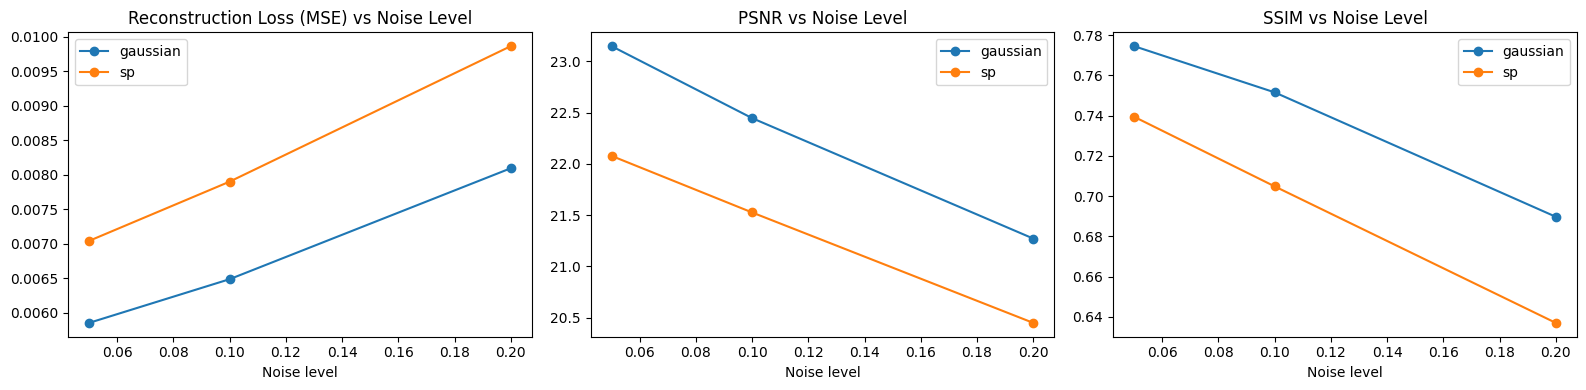

In [8]:
# ==============================
# Analysis 1: Effect of noise level on reconstruction quality
# ==============================
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for noise_type in noise_types:
    sub = results_df[results_df.noise_type == noise_type].groupby("noise_level").mean(numeric_only=True)
    axes[0].plot(sub.index, sub["val_recon_loss_mse"], marker='o', label=noise_type)
    axes[1].plot(sub.index, sub["psnr"], marker='o', label=noise_type)
    axes[2].plot(sub.index, sub["ssim"], marker='o', label=noise_type)

axes[0].set_title("Reconstruction Loss (MSE) vs Noise Level"); axes[0].set_xlabel("Noise level"); axes[0].legend()
axes[1].set_title("PSNR vs Noise Level"); axes[1].set_xlabel("Noise level"); axes[1].legend()
axes[2].set_title("SSIM vs Noise Level"); axes[2].set_xlabel("Noise level"); axes[2].legend()
plt.tight_layout(); plt.show()

                   val_recon_loss_mse       psnr      ssim
encoder decoder                                           
deep    transpose            0.011190  19.898305  0.571823
        unpool               0.006466  22.319253  0.769718
shallow transpose            0.007380  21.720092  0.721484
        unpool               0.005129  23.337601  0.801546


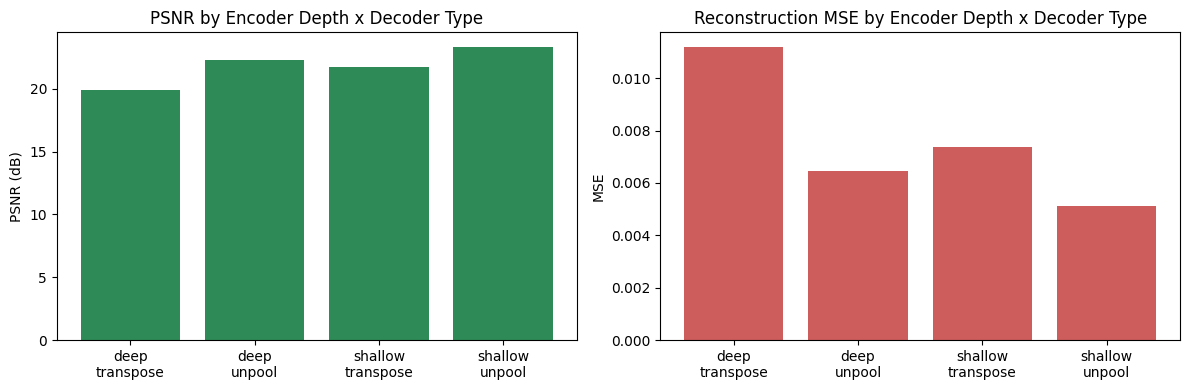

In [9]:
# ==============================
# Analysis 2: Impact of encoder depth and decoder (upsampling) type
# ==============================
arch_summary = results_df.groupby(["encoder", "decoder"]).mean(numeric_only=True)[["val_recon_loss_mse", "psnr", "ssim"]]
print(arch_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = [f"{e}\n{d}" for e, d in arch_summary.index]

axes[0].bar(labels, arch_summary["psnr"], color='seagreen')
axes[0].set_title("PSNR by Encoder Depth x Decoder Type"); axes[0].set_ylabel("PSNR (dB)")

axes[1].bar(labels, arch_summary["val_recon_loss_mse"], color='indianred')
axes[1].set_title("Reconstruction MSE by Encoder Depth x Decoder Type"); axes[1].set_ylabel("MSE")

plt.tight_layout(); plt.show()

Best configuration on the grid search:
 noise_type             gaussian
noise_level                0.05
encoder                 shallow
decoder                  unpool
val_recon_loss_mse     0.003155
psnr                  25.324508
ssim                   0.875217
Name: 1, dtype: object
Epoch 1/20
352/352 - 8s - 22ms/step - loss: 0.0109 - val_loss: 0.0031
Epoch 2/20
352/352 - 6s - 16ms/step - loss: 0.0026 - val_loss: 0.0023
Epoch 3/20
352/352 - 5s - 16ms/step - loss: 0.0021 - val_loss: 0.0020
Epoch 4/20
352/352 - 7s - 18ms/step - loss: 0.0019 - val_loss: 0.0018
Epoch 5/20
352/352 - 9s - 26ms/step - loss: 0.0018 - val_loss: 0.0017
Epoch 6/20
352/352 - 6s - 16ms/step - loss: 0.0017 - val_loss: 0.0017
Epoch 7/20
352/352 - 5s - 15ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 8/20
352/352 - 6s - 17ms/step - loss: 0.0016 - val_loss: 0.0016
Epoch 9/20
352/352 - 5s - 15ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 10/20
352/352 - 6s - 16ms/step - loss: 0.0015 - val_loss: 0.0015
Epoch 11/20


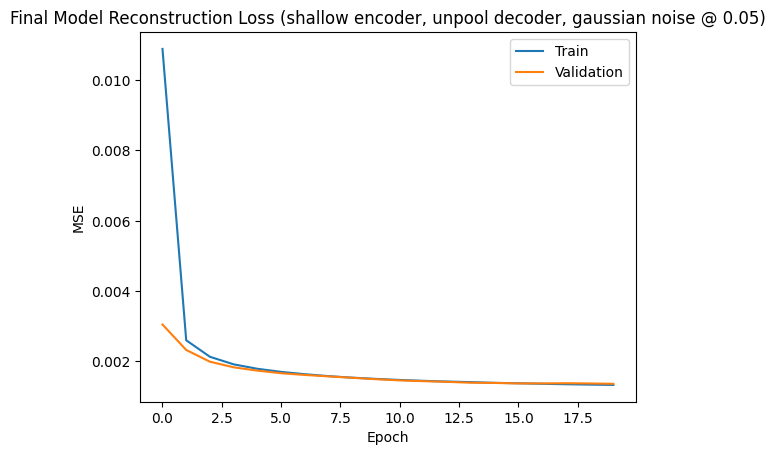


Held-out TEST set — Reconstruction Loss (MSE): 0.00136 | PSNR: 28.86 | SSIM: 0.929


In [13]:
# ==============================
# Final model: retrain the best (highest PSNR) configuration on the FULL
# training set, then visualize Original / Noisy / Denoised on the held-out
# TEST set.
# ==============================
best_row = results_df.loc[results_df["psnr"].idxmax()]
print("Best configuration on the grid search:\n", best_row)

best_noise_type = best_row["noise_type"]
best_level = best_row["noise_level"]
best_enc = best_row["encoder"]
best_dec = best_row["decoder"]

x_train_noisy_full = make_noisy(x_train, best_noise_type, best_level)
x_val_noisy_full = make_noisy(x_val, best_noise_type, best_level)
x_test_noisy_full = make_noisy(x_test, best_noise_type, best_level)

tf.keras.backend.clear_session()
final_model = build_model(best_enc, best_dec)
# Disable XLA compilation for `MaxPoolWithArgmax` compatibility
final_model.compile(optimizer='adam', loss='mse', jit_compile=False)

final_history = final_model.fit(
    x_train_noisy_full, x_train,
    epochs=20,
    batch_size=128,
    validation_data=(x_val_noisy_full, x_val),
    verbose=2
)

plt.plot(final_history.history['loss'], label='Train')
plt.plot(final_history.history['val_loss'], label='Validation')
plt.title(f"Final Model Reconstruction Loss ({best_enc} encoder, {best_dec} decoder, "
          f"{best_noise_type} noise @ {best_level})")
plt.xlabel("Epoch"); plt.ylabel("MSE"); plt.legend(); plt.show()

test_loss = final_model.evaluate(x_test_noisy_full, x_test, verbose=0)
decoded_test = final_model.predict(x_test_noisy_full, verbose=0)
test_psnr, test_ssim = evaluate_metrics(x_test, decoded_test)
print(f"\nHeld-out TEST set — Reconstruction Loss (MSE): {test_loss:.5f} | PSNR: {test_psnr:.2f} | SSIM: {test_ssim:.3f}")

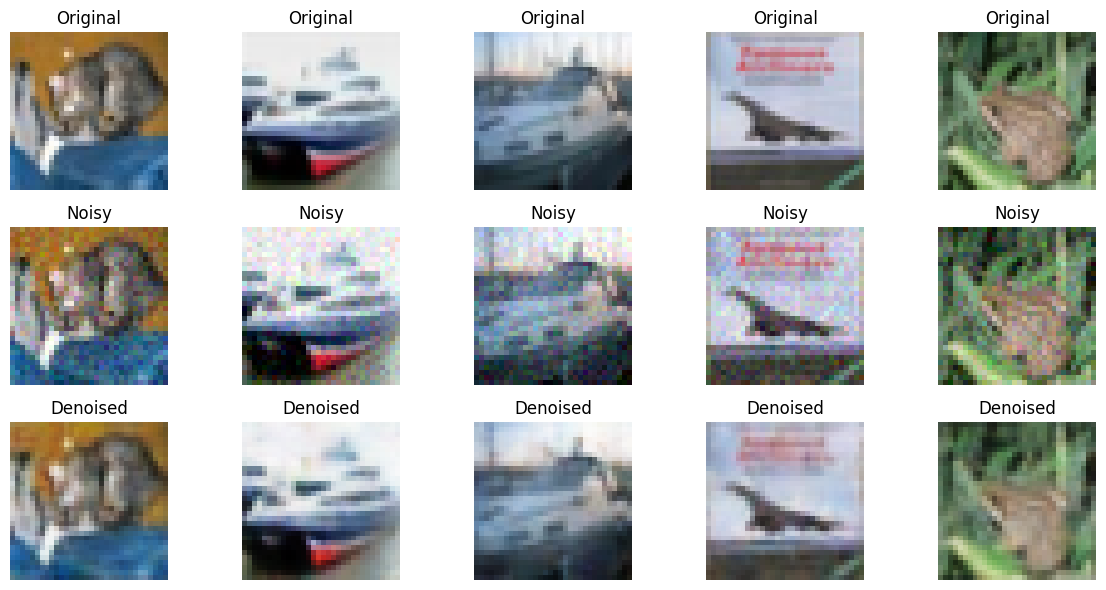

In [14]:
# ==============================
# Visualize: Original vs Noisy vs Denoised
# ==============================
def show_results(original, noisy, recon, n=5):
    plt.figure(figsize=(12, 6))
    for i in range(n):
        plt.subplot(3, n, i + 1); plt.imshow(original[i]); plt.title("Original"); plt.axis('off')
        plt.subplot(3, n, i + 1 + n); plt.imshow(noisy[i]); plt.title("Noisy"); plt.axis('off')
        plt.subplot(3, n, i + 1 + 2 * n); plt.imshow(np.clip(recon[i], 0, 1)); plt.title("Denoised"); plt.axis('off')
    plt.tight_layout(); plt.show()

show_results(x_test, x_test_noisy_full, decoded_test)

## Addressing limited annotated ground-truth data

A denoising autoencoder is already largely self-supervised — the "label" for a noisy image is just the clean version of the same image, so no manual annotation is required to train it. The real bottleneck is usually having enough **clean reference images** in the target domain. Practical ways to address that:

- **Self-supervised / Noise2Noise-style training** — if paired clean targets are unavailable, models can be trained to map one noisy observation to another independent noisy observation of the same scene; this converges to the same denoiser as training against a clean target, without ever needing ground truth.
- **Synthetic noise augmentation** — apply the noise functions above to any large *unlabeled* image collection to synthesize unlimited (noisy, clean) training pairs, without needing new annotation.
- **Transfer learning** — pretrain the encoder as a denoising autoencoder on a large, easily available dataset (e.g. ImageNet or unlabeled web images), then fine-tune only the decoder (or lightly fine-tune the whole network) on the small target dataset.
- **Semi-supervised consistency regularization** — combine a small labeled/clean set with a larger unlabeled set, encouraging the model to produce consistent reconstructions under different noise realizations of the same unlabeled image.
- **Active learning** — use reconstruction uncertainty (e.g. ensemble disagreement or high per-image reconstruction loss) to prioritize which additional images are worth acquiring clean references for, instead of annotating randomly.